# Wildfire Dataset Documentation

## Dataset Information
This notebook documents the combined wildfire datasets used for training and evaluation.

**Datasets Combined:**
- AI For Mankind Data
- Boreal Forest Fire Subset-C

**Location:** `data/` folder

---

## Part 1: Import Libraries and Setup

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import json

# Set data directory
DATA_DIR = Path("data")
IMAGES_DIR = DATA_DIR / "images"
LABELS_DIR = DATA_DIR / "labels"


Data directory: data
Exists: True


## Part 2: Count Images by Split

In [2]:
# Count images in each split
splits = ["train", "test", "valid"]
image_counts = {}
image_formats = defaultdict(int)

for split in splits:
    split_dir = IMAGES_DIR / split
    # Get all image files
    images = list(split_dir.glob("*.jpg")) + list(split_dir.glob("*.jpeg"))
    image_counts[split] = len(images)

    # Count file formats
    for img in images:
        image_formats[img.suffix] += 1

    print(f"\n{split.upper()} split:")
    print(f"  Total images: {len(images)}")

print(f"\n\nImage Format Distribution:")
for fmt, count in image_formats.items():
    print(f"  {fmt}: {count}")

# Summary
total_images = sum(image_counts.values())
print(f"\n\n{'='*50}")
print(f"TOTAL IMAGES: {total_images}")
print(f"{'='*50}")


TRAIN split:
  Total images: 3252

TEST split:
  Total images: 80

VALID split:
  Total images: 701


Image Format Distribution:
  .jpg: 1472
  .jpeg: 2561


TOTAL IMAGES: 4033


## Part 3: Check Image Properties (Size, Dimensions)

In [9]:
# Sample images and check properties
image_properties = defaultdict(list)

for split in splits:
    split_dir = IMAGES_DIR / split
    images = list(split_dir.glob("*.jpg")) + list(split_dir.glob("*.jpeg"))

    print(f"\n{split.upper()} - Sampling {min(5, len(images))} images:")

    for img_path in images[:5]:  # Sample first 5
        try:
            img = cv2.imread(str(img_path))
            if img is not None:
                h, w, c = img.shape
                file_size_mb = img_path.stat().st_size / (1024 * 1024)
                print(f"  {img_path.name}: {w}x{h}, {c} channels, {file_size_mb:.2f} MB")
                image_properties[split].append({"shape": (h, w, c), "size_mb": file_size_mb})
            else:
                print(f"  {img_path.name}: FAILED TO LOAD")
        except Exception as e:
            print(f"  {img_path.name}: ERROR - {e}")

# Calculate average resolution
print(f"\n\nAverage Image Dimensions:")
for split in splits:
    if image_properties[split]:
        heights = [p["shape"][0] for p in image_properties[split]]
        widths = [p["shape"][1] for p in image_properties[split]]
        avg_h = np.mean(heights)
        avg_w = np.mean(widths)
        print(f"  {split}: {avg_w:.0f}x{avg_h:.0f}")


TRAIN - Sampling 5 images:
  evoDJI_0001_frame0.jpg: 2048x1080, 3 channels, 0.18 MB
  evoDJI_0001_frame1.jpg: 2048x1080, 3 channels, 0.16 MB
  evoDJI_0001_frame10.jpg: 2048x1080, 3 channels, 0.20 MB
  evoDJI_0001_frame11.jpg: 2048x1080, 3 channels, 0.22 MB
  evoDJI_0001_frame12.jpg: 2048x1080, 3 channels, 0.27 MB

TEST - Sampling 5 images:
  evoDJI_0001_frame123.jpg: 2048x1080, 3 channels, 0.15 MB
  evoDJI_0001_frame128.jpg: 2048x1080, 3 channels, 0.26 MB
  evoDJI_0001_frame136.jpg: 2048x1080, 3 channels, 0.45 MB
  evoDJI_0001_frame143.jpg: 2048x1080, 3 channels, 0.38 MB
  evoDJI_0007_frame138.jpg: 2048x1080, 3 channels, 0.11 MB

VALID - Sampling 5 images:
  evoDJI_0007_frame1.jpg: 2048x1080, 3 channels, 0.29 MB
  evoDJI_0007_frame10.jpg: 2048x1080, 3 channels, 0.27 MB
  evoDJI_0007_frame11.jpg: 2048x1080, 3 channels, 0.27 MB
  evoDJI_0007_frame12.jpg: 2048x1080, 3 channels, 0.27 MB
  evoDJI_0007_frame13.jpg: 2048x1080, 3 channels, 0.27 MB


Average Image Dimensions:
  train: 2048x108

## Part 4: Check Labels and Masks

In [4]:
# Count label files
label_counts = {}
label_formats = defaultdict(int)
missing_labels = {}

for split in splits:
    labels_split_dir = LABELS_DIR / split
    images_split_dir = IMAGES_DIR / split

    # Get label files
    labels = list(labels_split_dir.glob("*.txt")) + list(labels_split_dir.glob("*.xml"))
    label_counts[split] = len(labels)

    # Count formats
    for lbl in labels:
        label_formats[lbl.suffix] += 1

    # Check for missing labels
    images = list(images_split_dir.glob("*.jpg")) + list(images_split_dir.glob("*.jpeg"))
    missing = 0

    for img in images:
        label_base = img.stem
        # Check if label exists (might be .txt or .xml)
        label_txt = labels_split_dir / f"{label_base}.txt"
        label_png = labels_split_dir / f"{label_base}.xml"
        if not (label_txt.exists() or label_png.exists()):
            missing += 1

    missing_labels[split] = missing

    print(f"\n{split.upper()} split:")
    print(f"  Total labels: {len(labels)}")
    print(f"  Missing labels: {missing}")

print(f"\n\nLabel Format Distribution:")
for fmt, count in label_formats.items():
    print(f"  {fmt}: {count}")


TRAIN split:
  Total labels: 3243
  Missing labels: 9

TEST split:
  Total labels: 80
  Missing labels: 0

VALID split:
  Total labels: 701
  Missing labels: 0


Label Format Distribution:
  .txt: 1463
  .xml: 2561


## Part 5: Visualize Sample Images with Labels

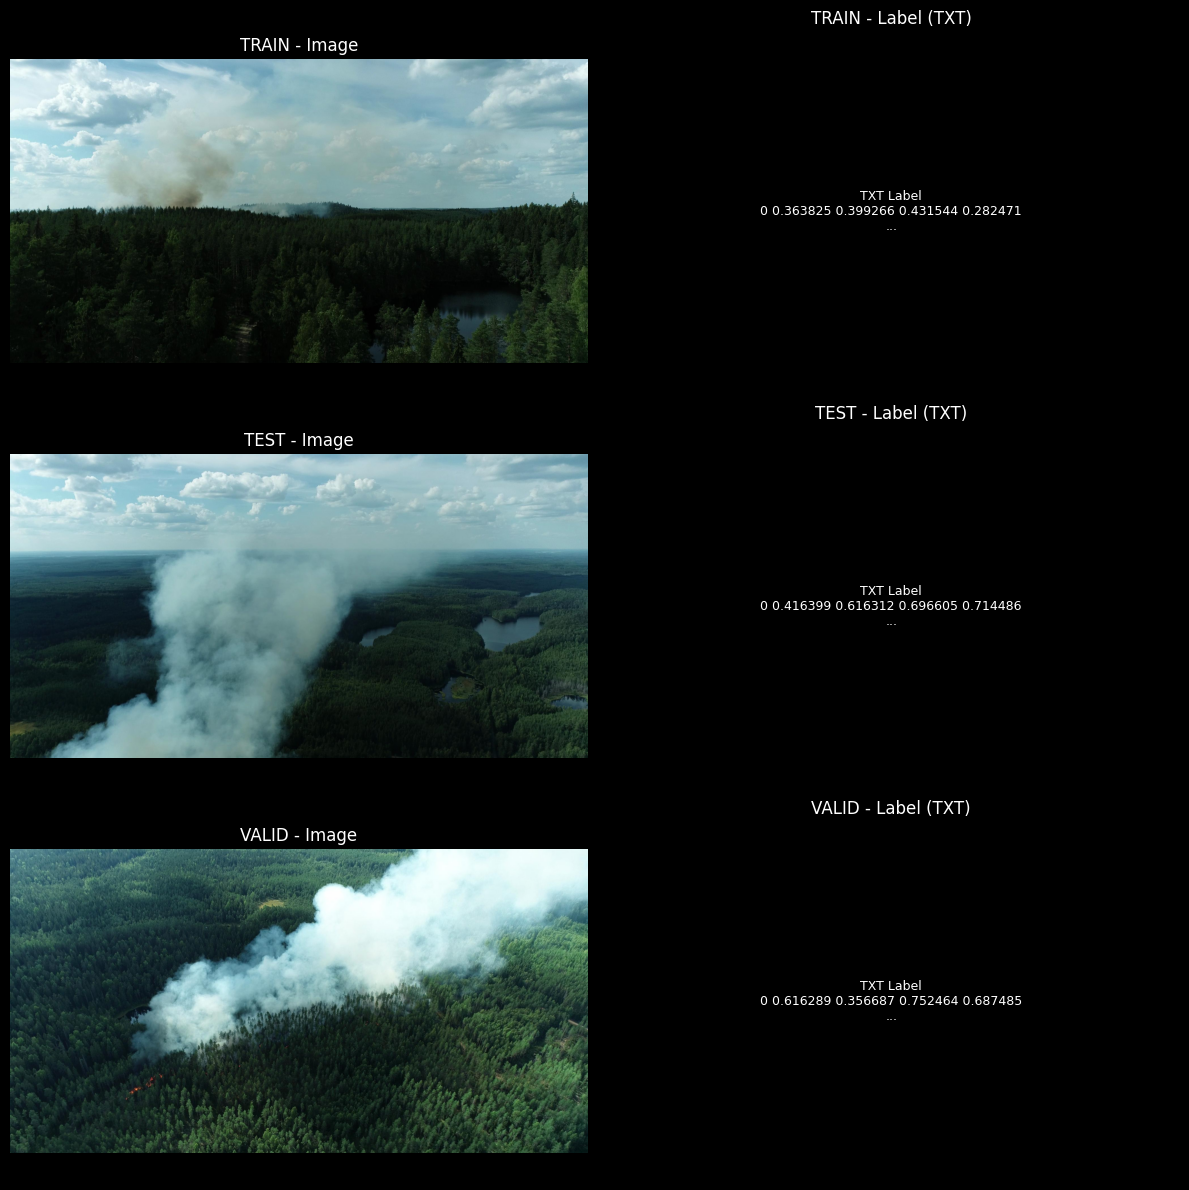


Sample visualization saved as 'dataset_samples.png'


In [6]:
# Visualize a few samples from each split
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for row, split in enumerate(splits):
    images_split_dir = IMAGES_DIR / split
    labels_split_dir = LABELS_DIR / split
    
    if images_split_dir.exists():
        images = list(images_split_dir.glob("*.jpg")) + list(images_split_dir.glob("*.jpeg"))

        # Load and display image
        img_path = images[0]
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(f"{split.upper()} - Image")
        axes[row, 0].axis("off")

        # Load and display label
        label_base = img_path.stem
        label_xml = labels_split_dir / f"{label_base}.xml"
        label_txt = labels_split_dir / f"{label_base}.txt"

        # Find which format exists
        label_path = None
        if label_xml.exists():
            label_path = label_xml
        elif label_txt.exists():
            label_path = label_txt

        if label_path and label_path.suffix == '.xml':
            # For XML files, just display the filename
            axes[row, 1].text(0.5, 0.5, f"XML Label\n({label_path.name})",
                              ha="center", va="center", fontsize=10, color="white")
            axes[row, 1].set_title(f"{split.upper()} - Label (XML)")
            axes[row, 1].set_facecolor("gray")

        elif label_path and label_path.suffix == '.txt':
            # For TXT files, display the content
            try:
                with open(label_path, 'r') as f:
                    content = f.read()[:100]  # Read first 100 chars
                axes[row, 1].text(0.5, 0.5, f"TXT Label\n{content}...",
                                  ha="center", va="center", fontsize=9, color="white")
                axes[row, 1].set_title(f"{split.upper()} - Label (TXT)")
                axes[row, 1].set_facecolor("gray")
            except:
                axes[row, 1].text(0.5, 0.5, "Error reading TXT", ha="center", va="center")
                axes[row, 1].set_title(f"{split.upper()} - Label (ERROR)")

        else:
            axes[row, 1].text(0.5, 0.5, "No label found", ha="center", va="center", color="white")
            axes[row, 1].set_title(f"{split.upper()} - Label (NOT FOUND)")
            axes[row, 1].set_facecolor("red")

        axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig("dataset_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSample visualization saved as 'dataset_samples.png'")

## Part 6: Create Dataset Summary Report

In [7]:
# Create summary report
summary = {
    "dataset_name": "Clemson Wildifre VLM (Combined Dataset)",
    "sources": [
        "AI For Mankind Data",
        "Boreal Forest Fire Subset-C"
    ],
    "image_counts": image_counts,
    "label_counts": label_counts,
    "missing_labels": missing_labels,
    "total_images": sum(image_counts.values()),
    "image_formats": dict(image_formats),
    "label_formats": dict(label_formats),
}

# Save as JSON
with open("dataset_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*50)
print("DATASET SUMMARY")
print("="*50)
print(json.dumps(summary, indent=2))
print("\nSummary saved as 'dataset_summary.json'")


DATASET SUMMARY
{
  "dataset_name": "Clemson Wildifre VLM (Combined Dataset)",
  "sources": [
    "AI For Mankind Data",
    "Boreal Forest Fire Subset-C"
  ],
  "image_counts": {
    "train": 3252,
    "test": 80,
    "valid": 701
  },
  "label_counts": {
    "train": 3243,
    "test": 80,
    "valid": 701
  },
  "missing_labels": {
    "train": 9,
    "test": 0,
    "valid": 0
  },
  "total_images": 4033,
  "image_formats": {
    ".jpg": 1472,
    ".jpeg": 2561
  },
  "label_formats": {
    ".txt": 1463,
    ".xml": 2561
  }
}

Summary saved as 'dataset_summary.json'
